In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("academic_performance.csv")

In [2]:
df.drop(columns=['Internal_Marks', 'External_Marks'], inplace=True)

In [3]:
df['Total_Marks'] = df['Total_Marks']/2

In [4]:
df.head()

,Student_ID,Gender,Age,Attendance_Percentage,Study_Hours_Per_Week,Total_Marks,Grade
0,1,male,22.0,81.0,11.0,69.0,D
1,2,FEMALE,17.0,88.0,16.0,60.0,C
2,3,Male,17.0,98.0,33.0,37.5,A
3,4,male,19.0,20.0,9.0,63.0,A
4,5,male,17.0,81.0,6.0,49.5,B


In [5]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Study_Hours_Per_Week', 'Total_Marks', 'Grade'],
      dtype='object')

In [6]:
df.shape

(100, 7)

In [7]:
df.describe()

,Student_ID,Age,Attendance_Percentage,Study_Hours_Per_Week,Total_Marks
count,100.000000,87.000000,98.000000,100.000000,96.000000
mean,50.500000,19.000000,74.224490,21.430000,40.322917
std,29.011492,2.156655,21.977275,12.618933,18.108297
min,1.000000,16.000000,20.000000,0.000000,3.000000
25%,25.750000,17.000000,60.000000,11.000000,25.625000
50%,50.500000,19.000000,77.000000,21.000000,42.000000
75%,75.250000,21.000000,88.000000,33.000000,54.500000
max,100.000000,22.000000,150.000000,60.000000,83.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             100 non-null    int64  
 1   Gender                 100 non-null    object 
 2   Age                    87 non-null     float64
 3   Attendance_Percentage  98 non-null     float64
 4   Study_Hours_Per_Week   100 non-null    float64
 5   Total_Marks            96 non-null     float64
 6   Grade                  100 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 5.6+ KB


In [9]:
df.isnull().sum()

Student_ID                0
Gender                    0
Age                      13
Attendance_Percentage     2
Study_Hours_Per_Week      0
Total_Marks               4
Grade                     0
dtype: int64

<Axes: >

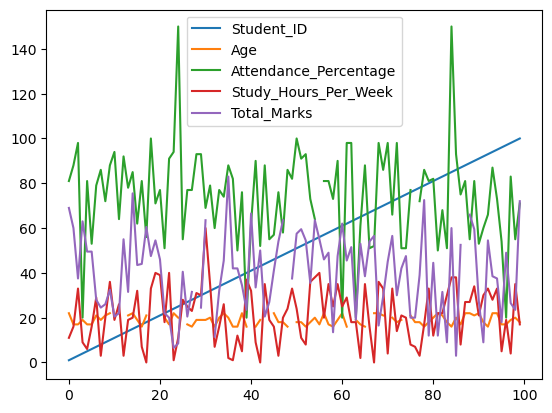

In [10]:
df.plot()

In [11]:
# df['Gender'].unique
df['Gender'] = df['Gender'].astype(str).str.lower()
df['Gender'] = df['Gender'].replace({'male':'M', 'female':'F'})

In [12]:
df.fillna({'Age':df['Age'].mean()}, inplace=True)
df.fillna({'Attendance_Percentage':df['Attendance_Percentage'].median()}, inplace=True)
# df.fillna({'Total_Marks': df['Total_Marks'].median()}, inplace=True)

In [13]:
df['Grade'].value_counts()

Grade
A            19
F            18
D            17
C            15
B            13
Fail         11
Excellent     7
Name: count, dtype: int64

In [14]:
df['Grade'] = df['Grade'].replace({'Fail':'F', 'Excellent':'A'})
# df.isnull().sum()

In [15]:
df['Total_Marks'].value_counts()

Total_Marks
37.5    3
63.5    3
20.5    3
31.5    3
42.0    3
       ..
66.0    1
27.5    1
18.0    1
26.5    1
72.0    1
Name: count, Length: 65, dtype: int64

In [16]:
grade_to_marks = {"A": 85, "B":70, "C":55, "D":40, "F":25}

df['Total_Marks'] = df['Total_Marks'].fillna(df['Grade'].map(grade_to_marks))

In [17]:
df.isnull().sum()

Student_ID               0
Gender                   0
Age                      0
Attendance_Percentage    0
Study_Hours_Per_Week     0
Total_Marks              0
Grade                    0
dtype: int64

In [18]:
df['Total_Marks'].value_counts()

Total_Marks
37.5    3
47.5    3
54.5    3
20.5    3
63.5    3
       ..
66.0    1
27.5    1
18.0    1
26.5    1
72.0    1
Name: count, Length: 68, dtype: int64

In [19]:
df["Attendance_Percentage"].describe()

count    100.000000
mean      74.280000
std       21.757655
min       20.000000
25%       60.000000
50%       77.000000
75%       88.000000
max      150.000000
Name: Attendance_Percentage, dtype: float64

In [20]:
Q1=np.percentile(df['Attendance_Percentage'],25,interpolation='midpoint')
Q3=np.percentile(df['Attendance_Percentage'],75,interpolation='midpoint')
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outliers = df[(df['Attendance_Percentage'] < lower) | (df['Attendance_Percentage'] > upper)]
print(outliers['Attendance_Percentage'])

24    150.0
84    150.0
Name: Attendance_Percentage, dtype: float64


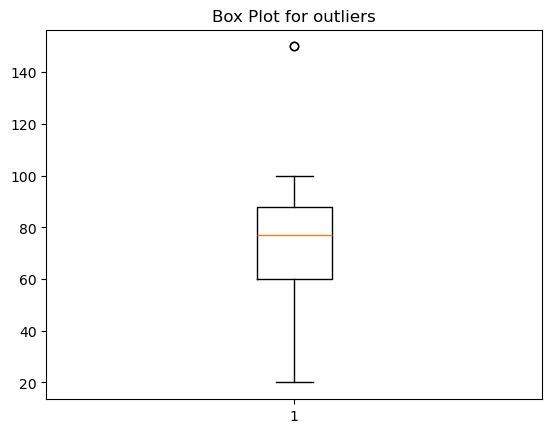

In [21]:
plt.boxplot(x=df['Attendance_Percentage'])
plt.title('Box Plot for outliers')
plt.show()

In [22]:
df["Attendance_Percentage"] = df["Attendance_Percentage"].clip(0, 100)

In [23]:
df['Attendance_Percentage'].describe()

count    100.000000
mean      73.280000
std       19.233325
min       20.000000
25%       60.000000
50%       77.000000
75%       88.000000
max      100.000000
Name: Attendance_Percentage, dtype: float64

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Marks scaled'] = scaler.fit_transform(df[['Total_Marks']])
df.head()

,Student_ID,Gender,Age,Attendance_Percentage,Study_Hours_Per_Week,Total_Marks,Grade,Marks scaled
0,1,M,22.0,81.0,11.0,69.0,D,0.82500
1,2,F,17.0,88.0,16.0,60.0,C,0.71250
2,3,M,17.0,98.0,33.0,37.5,A,0.43125
3,4,M,19.0,20.0,9.0,63.0,A,0.75000
4,5,M,17.0,81.0,6.0,49.5,B,0.58125


In [25]:
df.mean(numeric_only=True)

Student_ID               50.500000
Age                      19.000000
Attendance_Percentage    73.280000
Study_Hours_Per_Week     21.430000
Total_Marks              40.310000
Marks scaled              0.466375
dtype: float64

In [26]:
df.median(numeric_only=True)

Student_ID               50.50000
Age                      19.00000
Attendance_Percentage    77.00000
Study_Hours_Per_Week     21.00000
Total_Marks              41.50000
Marks scaled              0.48125
dtype: float64

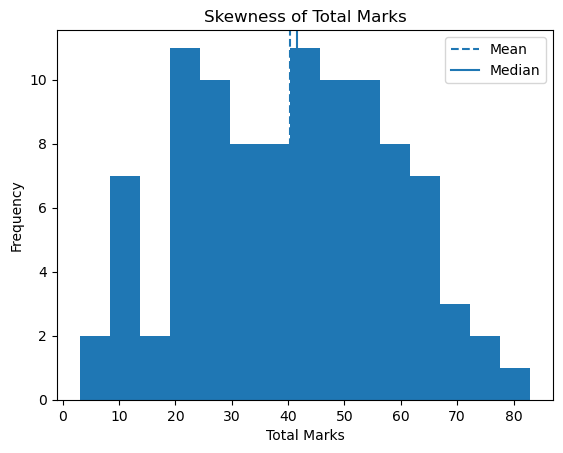

In [27]:
data = df["Total_Marks"]

plt.hist(data, bins=15)
plt.axvline(data.mean(), linestyle='--', label='Mean')
plt.axvline(data.median(), linestyle='-', label='Median')
plt.xlabel("Total Marks")
plt.ylabel("Frequency")
plt.title("Skewness of Total Marks")
plt.legend()
plt.show()


In [28]:
prev = df['Total_Marks'].skew()
df["Total_Marks_Log"] = np.log(df["Total_Marks"] + 1)
new = df['Total_Marks_Log'].skew()

prev, new

(np.float64(0.004332691318060714), np.float64(-1.2516233521772873))

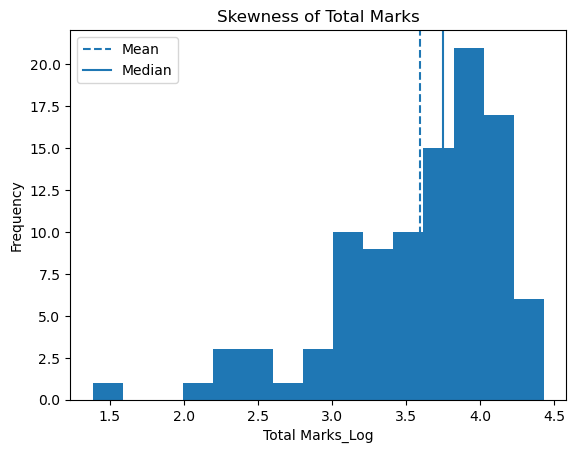

In [29]:
data = df["Total_Marks_Log"]

plt.hist(data, bins=15)
plt.axvline(data.mean(), linestyle='--', label='Mean')
plt.axvline(data.median(), linestyle='-', label='Median')
plt.xlabel("Total Marks_Log")
plt.ylabel("Frequency")
plt.title("Skewness of Total Marks")
plt.legend()
plt.show()